In [ ]:
import json
import warnings
warnings.filterwarnings('ignore')
from torchvision import models
import numpy as np
import cv2
import requests
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    deprocess_image, \
    preprocess_image
from PIL import Image

from src.model.models import get_model, get_device
from src.data.create_dataset import create_labels

Could not connect to 127.0.0.1: 62241
Traceback (most recent call last):
  File "/Applications/PyCharm.app/Contents/plugins/python/helpers/pydev/_pydevd_bundle/pydevd_comm.py", line 465, in start_client
    s.connect((host, port))
ConnectionRefusedError: [Errno 61] Connection refused
Traceback (most recent call last):
  File "/Applications/PyCharm.app/Contents/plugins/python/helpers-pro/jupyter_debug/pydev_jupyter_utils.py", line 81, in attach_to_debugger
    debugger.connect(pydev_localhost.get_localhost(), debugger_port)
  File "/Applications/PyCharm.app/Contents/plugins/python/helpers/pydev/pydevd.py", line 687, in connect
    s = start_client(host, port)
  File "/Applications/PyCharm.app/Contents/plugins/python/helpers/pydev/_pydevd_bundle/pydevd_comm.py", line 465, in start_client
    s.connect((host, port))
ConnectionRefusedError: [Errno 61] Connection refused
Failed to connect to target debugger.


In [2]:
with open('labels.json') as f:
    labels = json.load(f)
    
unique_labels = sorted(set(labels.values()))
class_map = {label: index for index, label in enumerate(unique_labels)}
print(class_map)

{'airplane': 0, 'backpack': 1, 'basket': 2, 'bed': 3, 'bicycle': 4, 'bread': 5, 'cabinet': 6, 'cake': 7, 'camera': 8, 'candle': 9, 'car_(automobile)': 10, 'chair': 11, 'clock': 12, 'cone': 13, 'frying_pan': 14, 'hat': 15, 'jacket': 16, 'laptop_computer': 17, 'microwave_oven': 18, 'motorcycle': 19, 'pie': 20, 'pizza': 21, 'sandwich': 22, 'shirt': 23, 'shoe': 24, 'sofa': 25, 'street_sign': 26, 'sweat_pants': 27, 'table': 28, 'television_set': 29, 'trash_can': 30, 'truck': 31}


In [3]:
import torch

model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_f_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
import glob

test_images_path = 'grad_cam_test/f'
test_images_labels_path = create_labels(test_images_path)
with open (test_images_labels_path) as f:
    test_images_labels = json.load(f)
test_images_paths = glob.glob(test_images_path + '/*.png')

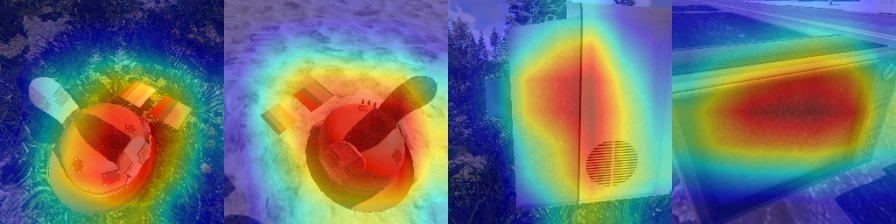

In [5]:
def grad_cam_on_image(test_images_paths,test_images_labels, model):
    cam_images = []
    for test_image_path in test_images_paths:
        img = np.array(Image.open(test_image_path))
        img = cv2.resize(img, (224, 224))
        img = np.float32(img) / 255
        input_tensor = preprocess_image(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        targets = [ClassifierOutputTarget(class_map[test_images_labels[test_image_path]])]
        target_layers = [model.layer4]
        with GradCAM(model=model, target_layers=target_layers) as cam:
            grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
            cam_image = show_cam_on_image(img, grayscale_cams[0, :], use_rgb=True)
        
        cam_images.append(cam_image)
    return cam_images, grayscale_cams

cam_images, grayscale_cams = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

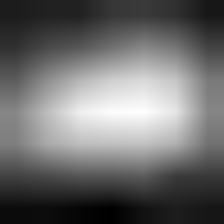

In [22]:
cam = np.uint8(255*grayscale_cams[0, :])
cam = cv2.merge([cam, cam, cam])
Image.fromarray(cam)

In [25]:
grayscale_cams[0, 128, 128]

0.8741324

In [24]:
cam[:,:,0]

array([[28, 28, 28, ..., 23, 23, 23],
       [28, 28, 28, ..., 23, 23, 23],
       [28, 28, 28, ..., 23, 23, 23],
       ...,
       [11, 11, 11, ..., 22, 22, 22],
       [11, 11, 11, ..., 22, 22, 22],
       [11, 11, 11, ..., 22, 22, 22]], dtype=uint8)

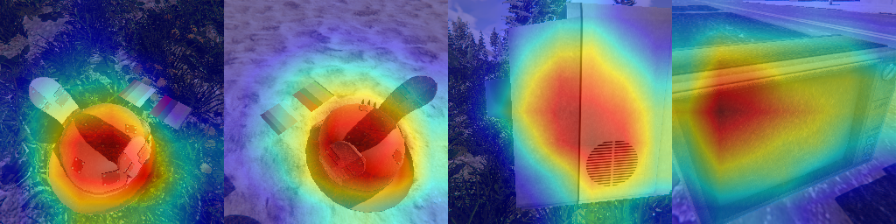

In [50]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_r_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

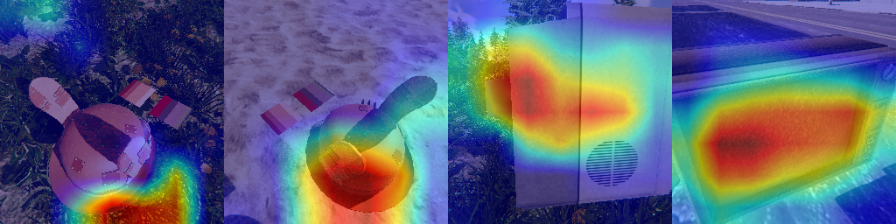

In [51]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_fx_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

In [52]:
test_images_path = 'grad_cam_test/r'
test_images_labels_path = create_labels(test_images_path)
with open (test_images_labels_path) as f:
    test_images_labels = json.load(f)
test_images_paths = glob.glob(test_images_path + '/*.png')

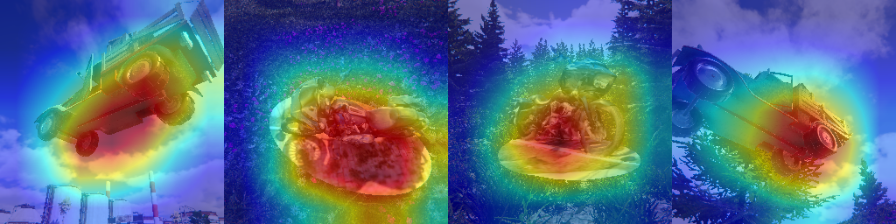

In [53]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_f_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

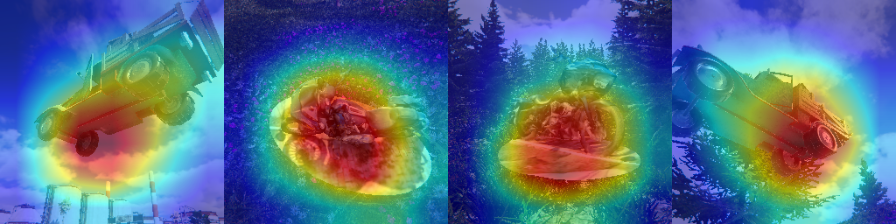

In [54]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_r_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

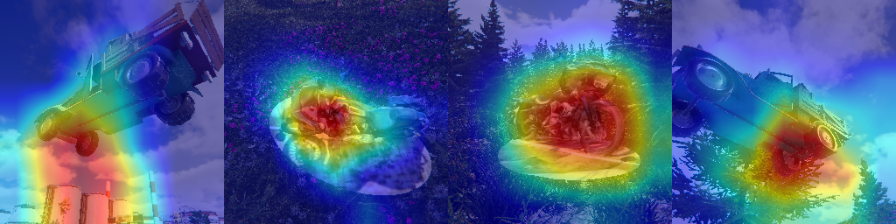

In [55]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_fx_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

In [56]:
test_images_path = 'grad_cam_test/fx'
test_images_labels_path = create_labels(test_images_path)
with open (test_images_labels_path) as f:
    test_images_labels = json.load(f)
test_images_paths = glob.glob(test_images_path + '/*.png')

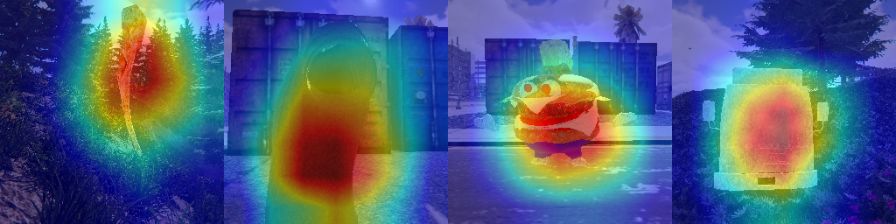

In [57]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_f_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

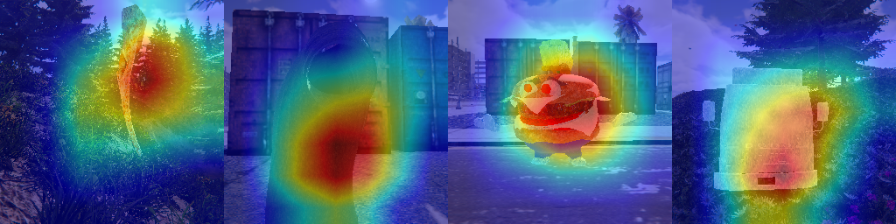

In [58]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_r_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)

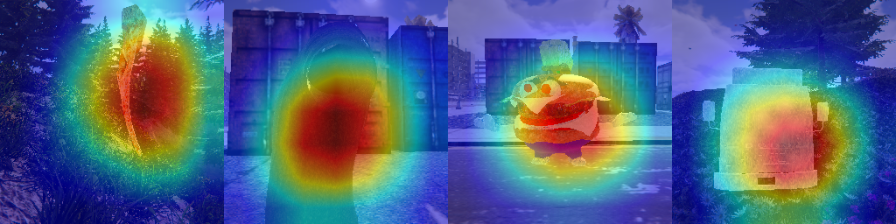

In [59]:
model, _ = get_model('resnet18', pretrained=False, num_classes=32)
device = get_device()
model.to(device)
state_dict = torch.load("../models/combined_fx_combined/resnet18_epoch_30.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

cam_images = grad_cam_on_image(test_images_paths, test_images_labels, model)
cam_images = np.hstack(cam_images)
Image.fromarray(cam_images)